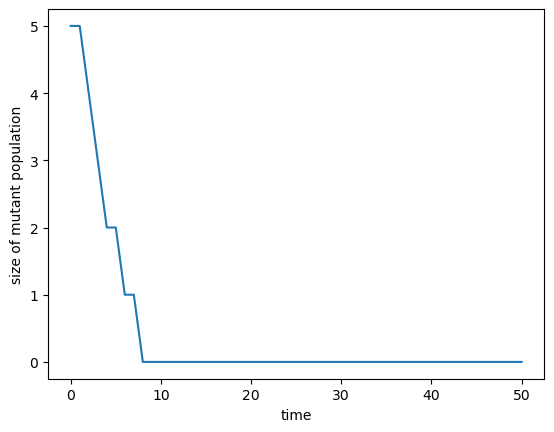

In [2]:
## ---------- Problem 1 ----------
import numpy as np
import numpy.random as rd
rng = rd.default_rng()
import matplotlib.pyplot as plt


# return probability of mutant being selected for birth
def probBirth(X, N):
    return X/N

# return probability of mutant being selected for death
def probDeath(X, N):
    return X/N

# Because the birth and death probabilities are the same, we can use a single function:
def probSelect(X, N):
    return X/N

# select which event occurs based on the probability P: if success (rv < P) return a 1, if fail return a 0
def mutantSelected(P):
    return rd.random() < P

T = 50
X0 = 5
N = 10
Y0 = N - X0
X_t = [X0,]
X = X0 # update during simulation
Y = Y0 # update during simulation
for t in range(T):

    Pmutant = probSelect(X, N)  #calculate probability of mutant being selected, given size X

    # ---- perform birth ----
    if mutantSelected(Pmutant):
        X += 1 # if a birth occurred, increase pop by 1

    # ---- perform death ----
    if mutantSelected(Pmutant):
        X -= 1

    X_t.append(X)


plt.plot(X_t)
plt.xlabel("time")
plt.ylabel("size of mutant population")
plt.show()

Text(0, 0.5, 'mutant population size')

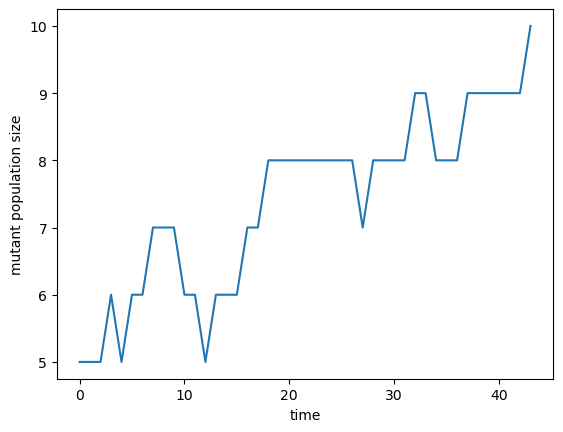

In [34]:
## ------------- Problem 2 -------------

def moranExperiment(X0, N):
    Y0 = N - X0
    X_t = [X0,]
    X = X0 # update during simulation
    fixation=False
    while not fixation:

        Pmutant = X/N #calculate probability of mutant being selected, given size X

        # ---- perform birth ----
        if rng.random()<Pmutant:
            X += 1 # if a birth occurred, increase pop by 1

        # ---- perform death ----
        if rng.random()<Pmutant:
            X -= 1 # if a death occurred, decrease pop by 1

        X_t.append(X)

        if X==0 or X==N:
            fixation=True
    
    return X_t

X_t = moranExperiment(5,10)

plt.plot(X_t)
plt.xlabel("time")
plt.ylabel("mutant population size")


In [37]:
# ----- b -----


N = 10
X0 = 5
experimentResults = [moranExperiment(X0,N) for i in range(1000)]

fixations = 0
for result in experimentResults:
    if result[-1]==N:
        fixations+=1

probFix = fixations / len(experimentResults)
print(probFix)

0.53
